# Project 4 — Sequence-to-Sequence Multi-Step Forecasting

So far every model predicted **one** step: given the past, guess the next value. But the real question is usually *"what happens over the next **H** steps?"* — the next 24 hours of load, the next week of demand. That is **multi-horizon forecasting**, and there are three classic ways to do it:

| strategy | how it makes H predictions | you already met it? |
|---|---|---|
| **Recursive** | train a *1-step* model, then feed its own prediction back in, H times | yes — Project 1's recursive forecast |
| **Direct** | one model outputs all H values *at once* from a single `Linear(hidden, H)` head | new (Step 5) |
| **Seq2Seq (encoder–decoder)** | an **encoder** RNN compresses the past into a hidden state; a **decoder** RNN unrolls it into H future steps, one at a time | new (Step 7) — the main event |

**Two big new ideas in this project:**
1. **Encoder–decoder**: two RNNs. The encoder reads the history and hands its final hidden state to the decoder as an initial "summary of the past." The decoder generates the future autoregressively.
2. **Teacher forcing & exposure bias**: during training we can feed the decoder the *ground-truth* previous value (fast, stable) instead of its own prediction — but then at test time it has never practiced running on its *own* (imperfect) outputs. That gap is **exposure bias**, and you'll measure it yourself in Step 10.

## Step 1 — Imports & device
*(provided)*

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Step 2 — Generate the data
*(provided)*

A univariate signal with a slow **trend**, a fast **daily** cycle (period 24), a slower **weekly** cycle (period 168), plus noise. Multi-step forecasting is interesting here precisely because the signal has structure at several time-scales — a good H-step forecast has to reproduce the *shape* of the next stretch, not just the next point.

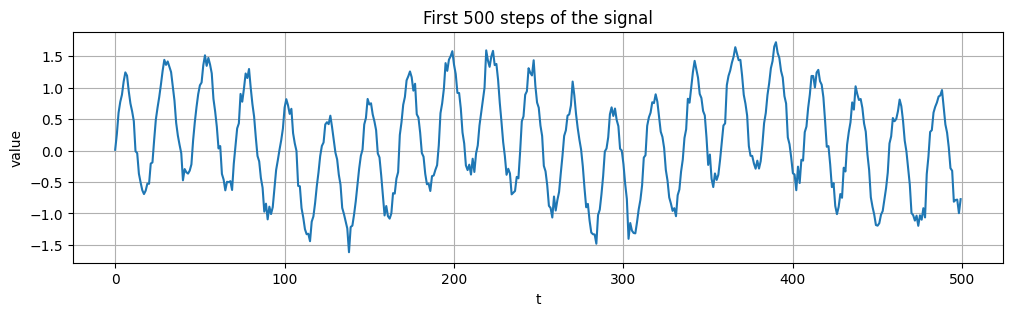

signal shape: (4000,)


In [2]:
rng = np.random.default_rng(0)
n = 4000
t = np.arange(n)

trend  = 0.0005 * t
daily  = np.sin(2 * np.pi * t / 24)
weekly = 0.5 * np.sin(2 * np.pi * t / 168)
signal = (trend + daily + weekly + 0.10 * rng.standard_normal(n)).astype(np.float32)

plt.figure(figsize=(12, 3))
plt.plot(signal[:500]); plt.title("First 500 steps of the signal")
plt.xlabel("t"); plt.ylabel("value"); plt.grid(True); plt.show()
print("signal shape:", signal.shape)

## Step 3 — Windows for seq2seq + scaling
*(provided)*

Each training example is now a **pair of sequences**:
- input  `X`: the last `ENC_LEN` known values, shape `(ENC_LEN, 1)`
- target `Y`: the next `HORIZON` values, shape `(HORIZON, 1)`

As always: fit the scaler on the **train** portion only, then split the *windows* by time.

In [3]:
ENC_LEN = 48    # how much history the encoder reads
HORIZON = 24    # how many future steps we predict at once

def make_windows_seq2seq(series, enc_len, horizon):
    X, Y = [], []
    for i in range(len(series) - enc_len - horizon + 1):
        X.append(series[i : i + enc_len])
        Y.append(series[i + enc_len : i + enc_len + horizon])
    X = np.asarray(X, dtype=np.float32)[..., None]   # (n, enc_len, 1)
    Y = np.asarray(Y, dtype=np.float32)[..., None]   # (n, horizon, 1)
    return X, Y

split = int(0.8 * n)
scaler = MinMaxScaler()
scaler.fit(signal[:split, None])                 # fit on train only
scaled = scaler.transform(signal[:, None]).ravel().astype(np.float32)

X_train, Y_train = make_windows_seq2seq(scaled[:split], ENC_LEN, HORIZON)
X_test,  Y_test  = make_windows_seq2seq(scaled[split - ENC_LEN:], ENC_LEN, HORIZON)
print("X_train:", X_train.shape, "| Y_train:", Y_train.shape)
print("X_test :", X_test.shape,  "| Y_test :", Y_test.shape)

X_train: (3129, 48, 1) | Y_train: (3129, 24, 1)
X_test : (777, 48, 1) | Y_test : (777, 24, 1)


## Step 4 — Dataset + DataLoader
*(provided — same pattern you built in Project 3)*

In [4]:
class SeqDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)
        self.Y = torch.from_numpy(Y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_dl = DataLoader(SeqDataset(X_train, Y_train), batch_size=64, shuffle=True)
test_dl  = DataLoader(SeqDataset(X_test,  Y_test),  batch_size=256, shuffle=False)

xb, yb = next(iter(train_dl))
print("batch X:", xb.shape, "| batch Y:", yb.shape)   # (64, ENC_LEN, 1) | (64, HORIZON, 1)

batch X: torch.Size([64, 48, 1]) | batch Y: torch.Size([64, 24, 1])


## Step 5 — 🛠️ Baseline: the *Direct* multi-output model

The simplest multi-step model: encode the history with one RNN, take the **last hidden state**, and use a single `Linear(hidden, HORIZON)` head to spit out all `H` future values in one shot. No decoder, no loop — the whole forecast is one matrix multiply.

**Why bother with this baseline?** It's the honest control. If the fancy encoder–decoder can't beat this, the extra machinery isn't earning its keep. Also, `Direct` has **no exposure bias** at all (it never feeds itself), so it's the natural thing to compare against in Step 10.

**🛠️ TODO:** two small changes, both marked below.
1. make the `fc` head output `HORIZON` values
2. in `forward`, take the last hidden state and reshape the output to `(batch, HORIZON, 1)` so it matches `Y`

In [5]:
class DirectForecaster(nn.Module):
    def __init__(self, hidden_size=64, horizon=HORIZON):
        super().__init__()
        self.horizon = horizon
        self.rnn = nn.GRU(1, hidden_size, batch_first=True)
        # 🛠️ TODO: an nn.Linear that maps hidden_size -> horizon
        self.fc = nn.Linear(hidden_size, horizon)   # replace me

    def forward(self, x):
        out, h = self.rnn(x)              # h: (1, batch, hidden)
        last = h[-1]                      # (batch, hidden)
        # 🛠️ TODO: apply self.fc, then reshape to (batch, horizon, 1)
        lin_out = self.fc(last)
        return lin_out[:,:, None]
        # raise NotImplementedError


direct = DirectForecaster(hidden_size=64).to(device)
with torch.no_grad():
    print("direct out:", direct(xb.to(device)).shape)   # expect (64, HORIZON, 1)

direct out: torch.Size([64, 24, 1])


## Step 6 — Train the Direct model
*(provided — the mini-batch loop you already know)*

In [6]:
def train_direct(model, epochs=30, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    hist = []
    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        hist.append(np.mean(batch_losses))
        if (epoch + 1) % 5 == 0:
            print(f"epoch {epoch+1:2d} | train MSE {hist[-1]:.5f}")
    return hist

direct_hist = train_direct(direct, epochs=30)

epoch  5 | train MSE 0.01972
epoch 10 | train MSE 0.00219
epoch 15 | train MSE 0.00161
epoch 20 | train MSE 0.00133
epoch 25 | train MSE 0.00128
epoch 30 | train MSE 0.00117


## Step 7 — 🛠️ The main event: Seq2Seq encoder–decoder with teacher forcing

Now the real thing. Two RNNs:
- **Encoder** reads the `ENC_LEN` history and produces a final hidden state `h` — a compressed summary of the past.
- **Decoder** starts from that `h` and generates the future **one step at a time**. At each step it takes the *previous value* as input, updates its hidden state, and emits the next prediction.

**The teacher-forcing decision (per step):** what is the decoder's input at step `t`?
- with **teacher forcing** → the *ground-truth* value `y[:, t-1]` (only available at training time)
- without → the decoder's *own* previous prediction

We flip a coin each step using `teacher_forcing_ratio`. At **eval time** we pass `y=None`, so the decoder must run entirely on its own outputs — exactly how it'll be used in production.

**🛠️ TODO:** complete the decoder loop. The skeleton and shapes are laid out for you; fill the three marked spots.

In [9]:
class Seq2Seq(nn.Module):
    def __init__(self, hidden_size=64, horizon=HORIZON):
        super().__init__()
        self.horizon = horizon
        self.encoder = nn.GRU(1, hidden_size, batch_first=True)
        self.decoder = nn.GRU(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, y=None, teacher_forcing_ratio=0.5):
        # x: (batch, enc_len, 1)   y: (batch, horizon, 1) or None
        _, h = self.encoder(x)             # h: (1, batch, hidden)  <- summary of the past
        dec_in = x[:, -1:, :]              # (batch, 1, 1)  first decoder input = last known value
        outputs = []
        for step in range(self.horizon):
            dec_out, h = self.decoder(dec_in, h)
            pred = self.fc(dec_out)
            outputs.append(pred)
            if self.training and y is not None and (torch.rand(1).item() < teacher_forcing_ratio):
                dec_in = y[:, step:step+1,:]
            else:
                dec_in = pred
            # 🛠️ TODO (1): run one decoder step: out, h = self.decoder(dec_in, h)
            # 🛠️ TODO (2): pred = self.fc(out)   -> shape (batch, 1, 1); append to outputs
            # 🛠️ TODO (3): choose next dec_in:
            #     if training AND coin-flip < teacher_forcing_ratio -> ground truth y[:, step:step+1, :]
            #     else -> the model's own pred
            # raise NotImplementedError
        return torch.cat(outputs, dim=1)   # (batch, horizon, 1)


seq2seq = Seq2Seq(hidden_size=64).to(device)
with torch.no_grad():
    print("seq2seq out (eval, y=None):", seq2seq(xb.to(device)).shape)   # expect (64, HORIZON, 1)

seq2seq out (eval, y=None): torch.Size([64, 24, 1])


## Step 8 — Train the Seq2Seq model
*(provided — note we pass `y=yb` and a teacher-forcing ratio during training)*

In [10]:
def train_seq2seq(model, epochs=30, lr=1e-3, teacher_forcing_ratio=0.5):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    hist = []
    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb, y=yb, teacher_forcing_ratio=teacher_forcing_ratio)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        hist.append(np.mean(batch_losses))
        if (epoch + 1) % 5 == 0:
            print(f"epoch {epoch+1:2d} | train MSE {hist[-1]:.5f}")
    return hist

seq2seq_hist = train_seq2seq(seq2seq, epochs=30, teacher_forcing_ratio=0.5)

epoch  5 | train MSE 0.00822
epoch 10 | train MSE 0.00299
epoch 15 | train MSE 0.00137
epoch 20 | train MSE 0.00178
epoch 25 | train MSE 0.00110
epoch 30 | train MSE 0.00106


## Step 9 — Evaluate: error vs horizon + sample forecasts
*(provided)*

Two things to look at:
1. **Per-horizon MSE**: error as a function of *how far ahead* we predict. It should **grow** with the horizon — predicting step +24 is harder than step +1. This curve is the signature of multi-step forecasting.
2. **Sample forecasts**: a few H-step predictions overlaid on the truth.

Direct   mean H-step MSE: 0.04766
Seq2Seq  mean H-step MSE: 0.09245


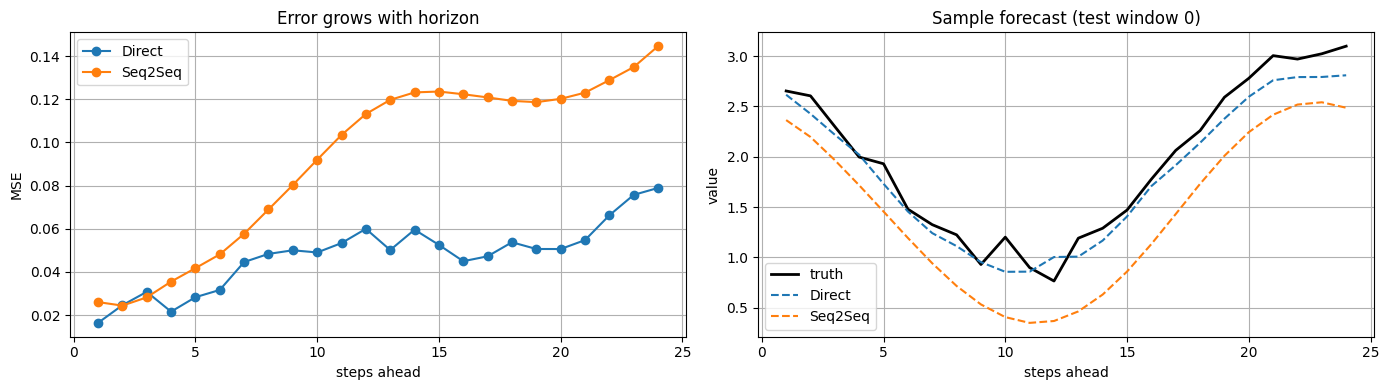

In [11]:
@torch.no_grad()
def evaluate(model):
    model.eval()
    preds = []
    for xb, yb in test_dl:
        preds.append(model(xb.to(device)).cpu().numpy())   # y=None -> free-running
    preds = np.concatenate(preds, axis=0)                  # (n, H, 1)
    # inverse-transform to original units
    inv = lambda a: scaler.inverse_transform(a.reshape(-1, 1)).reshape(a.shape)
    P, T = inv(preds), inv(Y_test)
    per_h_mse = ((P - T) ** 2).mean(axis=(0, 2))           # (H,)
    return P, T, per_h_mse

P_d, T, mse_d = evaluate(direct)
P_s, _, mse_s = evaluate(seq2seq)
print(f"Direct   mean H-step MSE: {mse_d.mean():.5f}")
print(f"Seq2Seq  mean H-step MSE: {mse_s.mean():.5f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(range(1, HORIZON + 1), mse_d, "-o", label="Direct")
ax[0].plot(range(1, HORIZON + 1), mse_s, "-o", label="Seq2Seq")
ax[0].set_xlabel("steps ahead"); ax[0].set_ylabel("MSE"); ax[0].set_title("Error grows with horizon")
ax[0].legend(); ax[0].grid(True)

s = 0   # which test window to visualize
ax[1].plot(range(1, HORIZON + 1), T[s, :, 0], "k-", linewidth=2, label="truth")
ax[1].plot(range(1, HORIZON + 1), P_d[s, :, 0], "--", label="Direct")
ax[1].plot(range(1, HORIZON + 1), P_s[s, :, 0], "--", label="Seq2Seq")
ax[1].set_xlabel("steps ahead"); ax[1].set_ylabel("value"); ax[1].set_title(f"Sample forecast (test window {s})")
ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()

epoch  5 | train MSE 0.00185
epoch 10 | train MSE 0.00091
epoch 15 | train MSE 0.00078
epoch 20 | train MSE 0.00074
epoch 25 | train MSE 0.00071
epoch 30 | train MSE 0.00069
epoch  5 | train MSE 0.00660
epoch 10 | train MSE 0.00134
epoch 15 | train MSE 0.00108
epoch 20 | train MSE 0.00101
epoch 25 | train MSE 0.00093
epoch 30 | train MSE 0.00086
epoch  5 | train MSE 0.02855
epoch 10 | train MSE 0.00451
epoch 15 | train MSE 0.00270
epoch 20 | train MSE 0.00151
epoch 25 | train MSE 0.00123
epoch 30 | train MSE 0.00127


ValueError: x and y must have same first dimension, but have shapes (50,) and (24,)

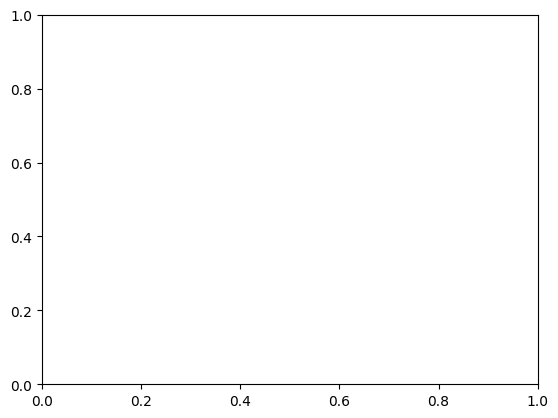

In [12]:
results = {}
for tf in [1.0, 0.5, 0.0]:
    m = Seq2Seq(hidden_size=64).to(device)
    train_seq2seq(m, epochs=30, teacher_forcing_ratio=tf)
    _,_,mse =evaluate(m)
    results[tf] = mse


In [15]:
results[1.0].shape

(24,)

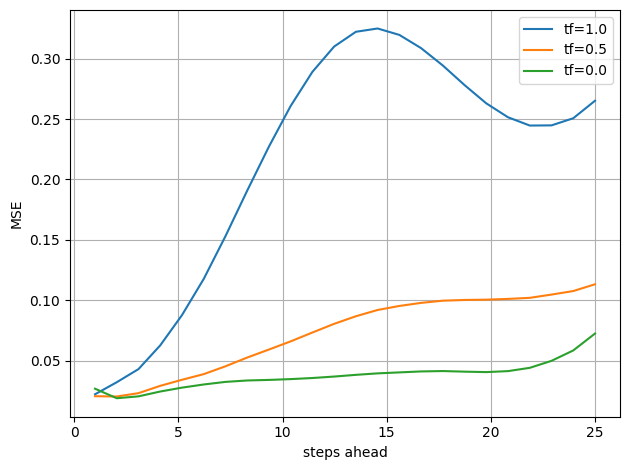

In [18]:

fig, ax = plt.subplots()
ax.plot(np.linspace(1, 24+1, 24), results[1.0], label='tf=1.0')
ax.plot(np.linspace(1, 24+1, 24), results[0.5], label='tf=0.5')
ax.plot(np.linspace(1, 24+1, 24), results[0.0], label='tf=0.0')
ax.set_xlabel('steps ahead')
ax.set_ylabel('MSE')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

## Step 10 — 🛠️ Exposure bias: the teacher-forcing experiment

This is the payoff. Teacher forcing makes training easy — but a decoder trained with **`teacher_forcing_ratio=1.0`** has *never once* seen its own imperfect predictions during training. At test time it always runs free (`y=None`), so small errors at step +1 feed into step +2 and **compound**. That train/test mismatch is **exposure bias**.

**🛠️ TODO — run the sweep.** Train three *fresh* `Seq2Seq` models with `teacher_forcing_ratio` = `1.0`, `0.5`, `0.0`, evaluate each, and plot their per-horizon MSE curves on one axis.

```python
results = {}
for tf in [1.0, 0.5, 0.0]:
    m = Seq2Seq(hidden_size=64).to(device)
    train_seq2seq(m, epochs=30, teacher_forcing_ratio=tf)
    _, _, mse = evaluate(m)
    results[tf] = mse
# then plot results[1.0], results[0.5], results[0.0] vs steps-ahead
```

**Write your prediction first, then test it:**
> My prediction: the tf=1.0 curve will __be worse__ at long horizons compared to tf=0.0/0.5, because __during training the model has never seen its own imperfect predictions__

**Then answer:**
1. Which `teacher_forcing_ratio` gives the best **long-horizon** (steps +18…+24) test MSE? Does it match your prediction?
> I predict tf=0.5 should give the best results. Interestingly `tf=0.0` gives the best results
2. Look at the **early** horizons (steps +1…+3). Does tf=1.0 look good there? Why can early-horizon quality *hide* the exposure-bias problem?
> Even at **early** horizons tf=1.0 does not look good for this run. But it can happen because then the model only trained on true target will see the actual imperfect predictions at the evaluation time and the imperfect predictions fed back will have a compounding effect
1. Why does `Direct` (Step 5) have **no** exposure bias at all? What does it give up in exchange? (Hint: does it model dependencies *between* the H outputs?) -> Direct dodges exposure bias by refusing to be autoregressive &ndash; and pays for it by being unable to coupe its own outputs.
2. **Scheduled sampling** starts training near tf=1.0 and anneals toward tf=0.0 over epochs. In one sentence, why might that beat any *fixed* ratio? -> It can acutally work better because we start with actual targets and later tune the model with real imperfect predictions.So you get fast early convergence and test-time robustness.

### Summary
1. Encoder-Decoder architecture with teacher forcing helps model autoregressive dependencies among outputs.
2. An NN architecture is problem dependent; if the problem does not need the capability, the simpler model wins.
3. Exposure bias is when the RNN encoder-decoder framework runs with tf=1.0, in this case it never sees its own imperfect predictions hence during test small error at step one feedbacks again and again making error compund. This compounding effect increases as long range history and it is called **Exposure Bias**